     a/M      Mw_R      Mw_I       A_R       A_I   BTeuk_R   BTeuk_I  \
0  0.000  0.747343 -0.177925  4.000000  0.000000  0.025587 -0.016876   
1  0.001  0.747595 -0.177921  3.999003  0.000237  0.025652 -0.016875   
2  0.002  0.747847 -0.177917  3.998005  0.000475  0.025718 -0.016874   
3  0.003  0.748099 -0.177913  3.997007  0.000712  0.025783 -0.016873   
4  0.004  0.748352 -0.177908  3.996007  0.000950  0.025848 -0.016872   

      BSN_R     BSN_I          w_R         w_I           f       tau  
0  0.126902  0.020315  1264.414346 -301.026896  201.237793 -0.003322  
1  0.126859  0.020417  1264.840141 -301.020128  201.305561 -0.003322  
2  0.126816  0.020518  1265.266444 -301.013327  201.373409 -0.003322  
3  0.126773  0.020620  1265.693220 -301.006475  201.441332 -0.003322  
4  0.126729  0.020722  1266.120488 -300.999606  201.509334 -0.003322  
     a/M      Mw_R      Mw_I       A_R       A_I   BTeuk_R   BTeuk_I  \
0  0.000  0.693422 -0.547830  4.000000  0.000000 -0.081122  0.067715 

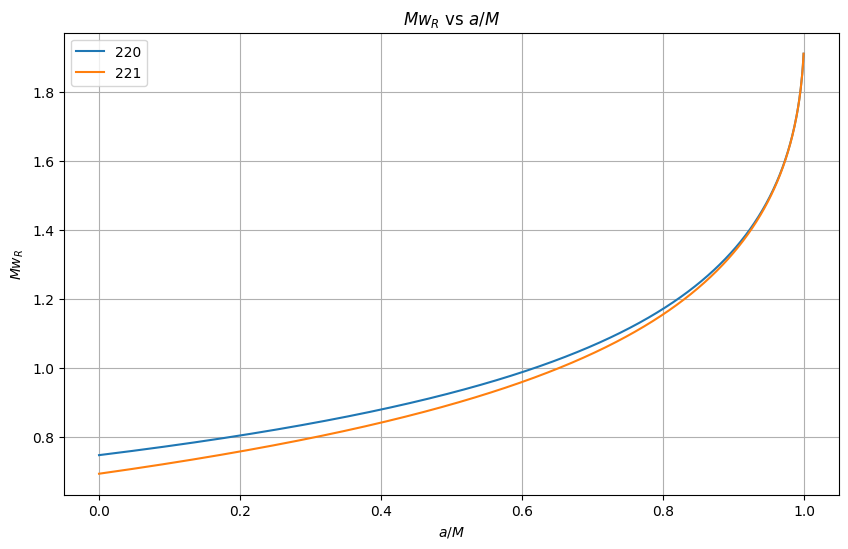

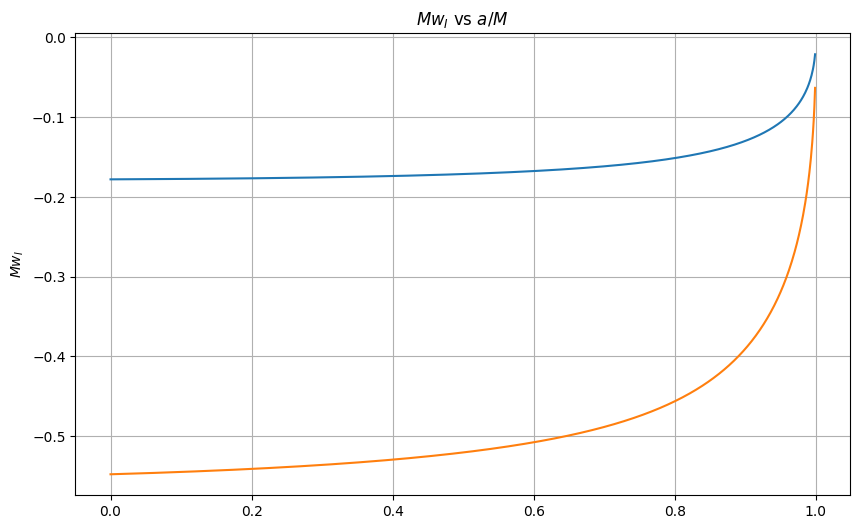

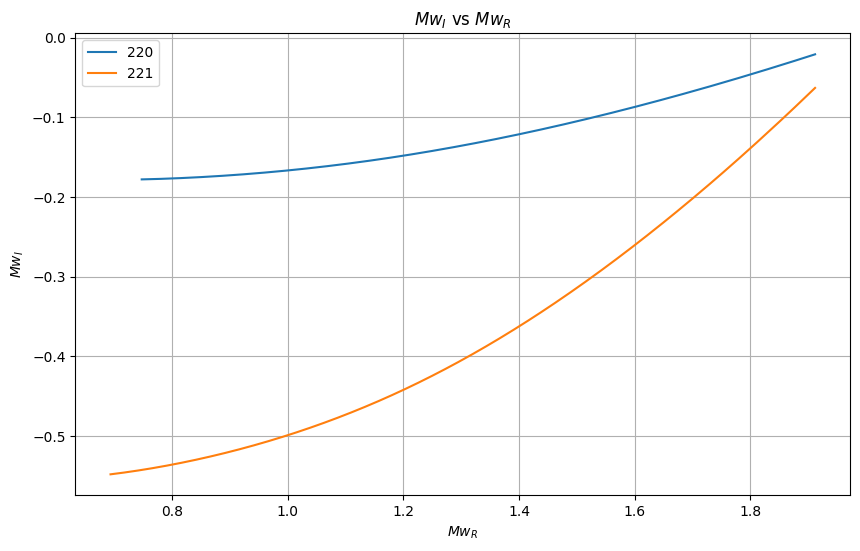

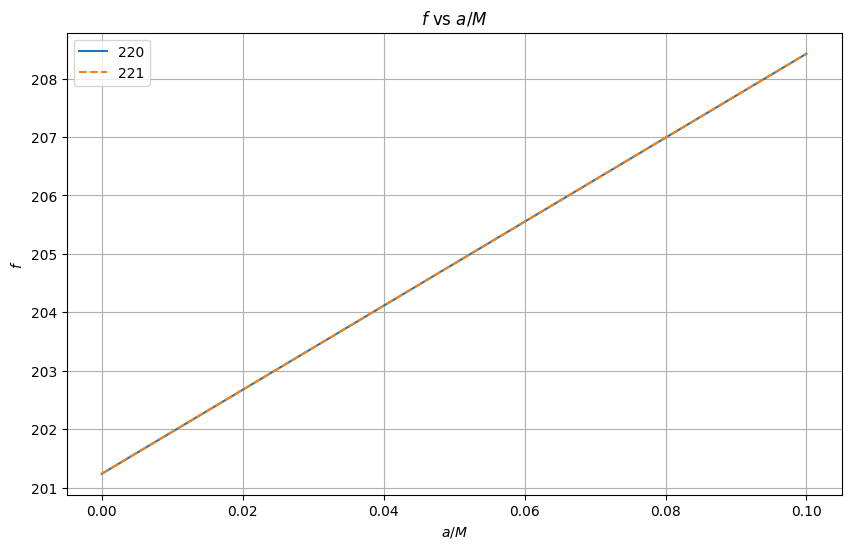

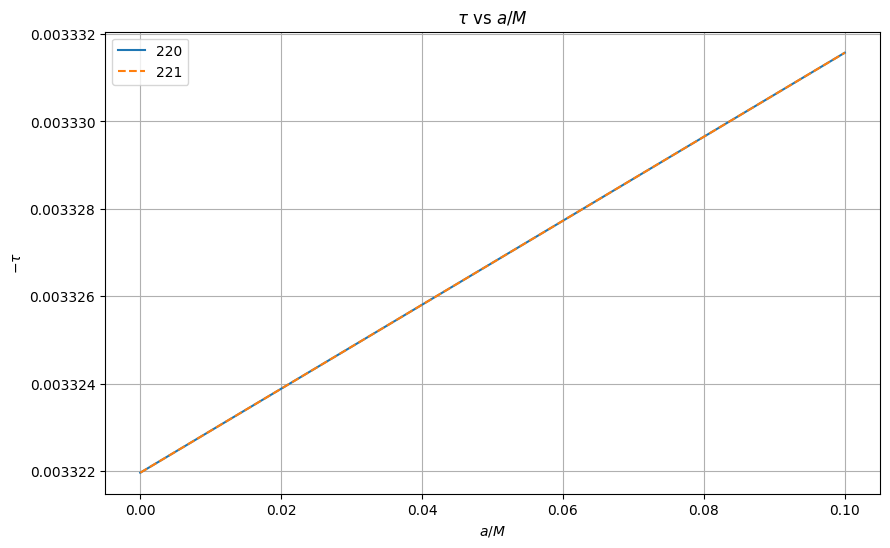

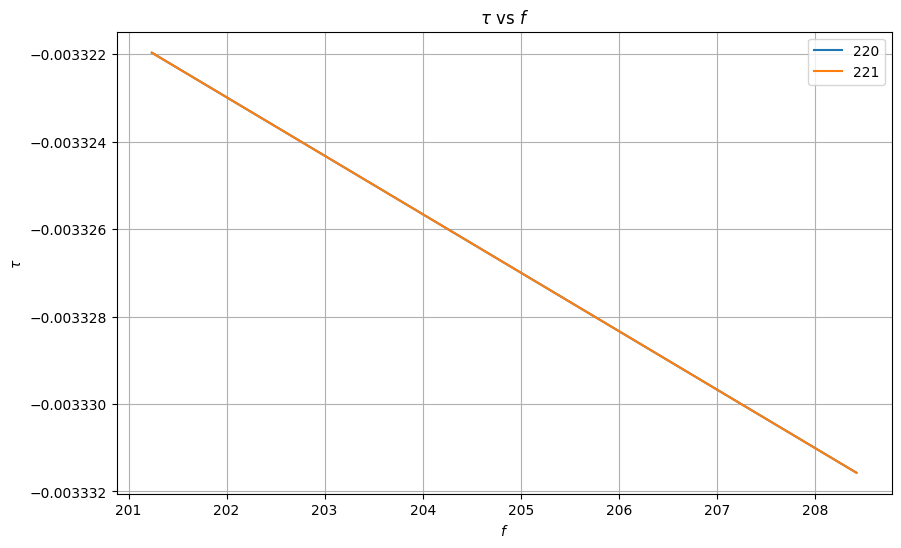

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import astropy.constants as const

###constants###
Mo = const.M_sun.value #solar mass [kg]
G = const.G.value #Newton constant [m^3 kg^-1 s^-2]
c = const.c.value #light speed [m s^-1]
pc = const.pc.value #1pc [m]
###############

# data = np.loadtxt('./s2/l2/Bl2m2n0.dat')
# print(data.shape)  # 形状確認 (行数, 9列)
# print(data)

M = 2* 60 * Mo * G / c**3

df_220 = pd.read_csv('./s2/l2/Bl2m2n0.dat', delim_whitespace=True, header=None)
df_221 = pd.read_csv('./s2/l2/Bl2m2n1.dat', delim_whitespace=True, header=None)
df_220.columns = ['a/M' ,'Mw_R', 'Mw_I', 'A_R', 'A_I', 'BTeuk_R', 'BTeuk_I', 'BSN_R', 'BSN_I']
df_221.columns = ['a/M' ,'Mw_R', 'Mw_I', 'A_R', 'A_I', 'BTeuk_R', 'BTeuk_I', 'BSN_R', 'BSN_I']

df_220['w_R'] = df_220['Mw_R'] / M
df_220['w_I'] = df_220['Mw_I'] / M
df_220['f'] = df_220['w_R'] / (2 * np.pi)
df_220['tau'] = 1 / df_220['w_I']

df_221['w_R'] = df_220['Mw_R'] / M
df_221['w_I'] = df_220['Mw_I'] / M
df_221['f'] = df_220['w_R'] / (2 * np.pi)
df_221['tau'] = 1 / df_220['w_I']

print(df_220.head())
print(df_221.head())

plt.figure(figsize=(10, 6))
plt.plot(df_220['a/M'], df_220['Mw_R'], label='220')
plt.plot(df_221['a/M'], df_221['Mw_R'], label='221')
plt.legend()
plt.xlabel(r'$a/M$')
plt.ylabel(r'$Mw_R$')
plt.title(r'$Mw_R$ vs $a/M$')
plt.grid()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(df_220['a/M'], df_220['Mw_I'], label='220')
plt.plot(df_221['a/M'], df_221['Mw_I'], label='221')
plt.ylabel(r'$Mw_I$')
plt.title(r'$Mw_I$ vs $a/M$')
plt.grid()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(df_220['Mw_R'], df_220['Mw_I'], label='220')
plt.plot(df_221['Mw_R'], df_221['Mw_I'], label='221')
plt.legend()
plt.xlabel(r'$Mw_R$')
plt.ylabel(r'$Mw_I$')
plt.title(r'$Mw_I$ vs $Mw_R$')
plt.grid()
plt.show()

plot_range = [0, 100]
plt.figure(figsize=(10, 6))
plt.plot(df_220['a/M'][plot_range], df_220['f'][plot_range], label='220')
plt.plot(df_221['a/M'][plot_range], df_221['f'][plot_range], label='221', ls='--')
plt.xlabel(r'$a/M$')
plt.ylabel(r'$f$')
# plt.xscale('log')
# plt.yscale('log')
# plt.xlim(0, 0.1)
# plt.ylim(0, 1000)
plt.legend()
plt.title(r'$f$ vs $a/M$')
plt.grid()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(df_220['a/M'][plot_range], -df_220['tau'][plot_range], label='220')
plt.plot(df_221['a/M'][plot_range], -df_221['tau'][plot_range], label='221', ls='--')
plt.legend()
plt.xlabel(r'$a/M$')
plt.ylabel(r'$-\tau$')
# plt.xscale('log')
# plt.yscale('log')
# plt.xlim(0, 0.1)
# plt.ylim(0, 1000)
plt.legend()
plt.title(r'$\tau$ vs $a/M$')
plt.grid()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(df_220['f'][plot_range], df_220['tau'][plot_range], label='220')
plt.plot(df_221['f'][plot_range], df_221['tau'][plot_range], label='221')
plt.legend()
plt.xlabel(r'$f$')
plt.ylabel(r'$\tau$')
plt.title(r'$\tau$ vs $f$')
plt.grid()
plt.show()
plt.show()

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import astropy.constants as const

###constants###
Mo = const.M_sun.value #solar mass [kg]
G = const.G.value #Newton constant [m^3 kg^-1 s^-2]
c = const.c.value #light speed [m s^-1]
pc = const.pc.value #1pc [m]
###############

# data = np.loadtxt('./s2/l2/Bl2m2n0.dat')
# print(data.shape)  # 形状確認 (行数, 9列)
# print(data)

M = 2* 60 * Mo * G / c**3

df_225 = pd.read_csv('./s2/l2/Bl2m2n5.dat', delim_whitespace=True, header=None)
df_226 = pd.read_csv('./s2/l2/Bl2m2n6.dat', delim_whitespace=True, header=None)
df_225.columns = ['a/M' ,'Mw_R', 'Mw_I', 'A_R', 'A_I', 'BTeuk_R', 'BTeuk_I', 'BSN_R', 'BSN_I']
df_226.columns = ['a/M' ,'Mw_R', 'Mw_I', 'A_R', 'A_I', 'BTeuk_R', 'BTeuk_I', 'BSN_R', 'BSN_I']

df_225['w_R'] = df_225['Mw_R'] / M
df_225['w_I'] = df_225['Mw_I'] / M
df_225['f'] = df_225['w_R'] / (2 * np.pi)
df_225['tau'] = 1 / df_225['w_I']

df_226['w_R'] = df_226['Mw_R'] / M
df_226['w_I'] = df_226['Mw_I'] / M
df_226['f'] = df_226['w_R'] / (2 * np.pi)
df_226['tau'] = 1 / df_226['w_I']

print(df_225.head())
print(df_226.head())

plt.figure(figsize=(10, 6))
plt.plot(df_225['a/M'], df_225['Mw_R'], label='225')
plt.plot(df_226['a/M'], df_226['Mw_R'], label='226')
plt.legend()
plt.xlabel(r'$a/M$')
plt.ylabel(r'$Mw_R$')
plt.title(r'$Mw_R$ vs $a/M$')
plt.grid()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(df_225['a/M'], df_225['Mw_I'], label='225')
plt.plot(df_226['a/M'], df_226['Mw_I'], label='226')
plt.ylabel(r'$Mw_I$')
plt.title(r'$Mw_I$ vs $a/M$')
plt.grid()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(df_225['Mw_R'], df_225['Mw_I'], label='225')
plt.plot(df_226['Mw_R'], df_226['Mw_I'], label='226')
plt.legend()
plt.xlabel(r'$Mw_R$')
plt.ylabel(r'$Mw_I$')
plt.title(r'$Mw_I$ vs $Mw_R$')
plt.grid()
plt.show()

plot_range = [0, 100]
plt.figure(figsize=(10, 6))
plt.plot(df_225['a/M'][plot_range], df_225['f'][plot_range], label='225')
plt.plot(df_226['a/M'][plot_range], df_226['f'][plot_range], label='226', ls='--')
plt.xlabel(r'$a/M$')
plt.ylabel(r'$f$')
# plt.xscale('log')
# plt.yscale('log')
# plt.xlim(0, 0.1)
# plt.ylim(0, 1000)
plt.legend()
plt.title(r'$f$ vs $a/M$')
plt.grid()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(df_225['a/M'][plot_range], -df_225['tau'][plot_range], label='225')
plt.plot(df_226['a/M'][plot_range], -df_226['tau'][plot_range], label='226', ls='--')
plt.legend()
plt.xlabel(r'$a/M$')
plt.ylabel(r'$-\tau$')
# plt.xscale('log')
# plt.yscale('log')
# plt.xlim(0, 0.1)
# plt.ylim(0, 1000)
plt.legend()
plt.title(r'$\tau$ vs $a/M$')
plt.grid()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(df_225['f'][plot_range], df_225['tau'][plot_range], label='225')
plt.plot(df_226['f'][plot_range], df_226['tau'][plot_range], label='226')
plt.legend()
plt.xlabel(r'$f$')
plt.ylabel(r'$\tau$')
plt.title(r'$\tau$ vs $f$')
plt.grid()
plt.show()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: './s2/l2/Bl2m2n5.dat'